# Task 1: Bank Marketing Prediction
## Introduction

Banks spend millions on marketing campaigns to convince customers to invest in 
term deposits. Not every customer accepts the offer, so predicting who is likely
to subscribe helps banks save money and improve campaign success.

# Problem Statement

A bank wants to identify customers who are likely to subscribe to a term deposit after receiving a marketing campaign.

Instead of contacting every customer, the bank wants to use machine learning to predict potential subscribers and target only those customers.

# Objective

Develop a binary classification model that predicts whether a customer will subscribe to a term deposit.

The model should:

Analyze customer information
Learn patterns from historical data
Predict new customers
Explain predictions using XAI (SHAP/LIME)

# Load Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# load Data set 
df = pd.read_csv("bank.csv")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


# Data Cleaning And Understanding

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [8]:
# data statistic description
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [9]:
# check Null Values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [11]:
# check Duplicates 
df.duplicated().sum()

np.int64(0)

In [12]:
# Check Rows And Columns
print("Rows:",df.shape[0],"Columns",df.shape[1])

Rows: 11162 Columns 17


# Data Analysis

In [13]:
# check subscription
df.deposit.value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

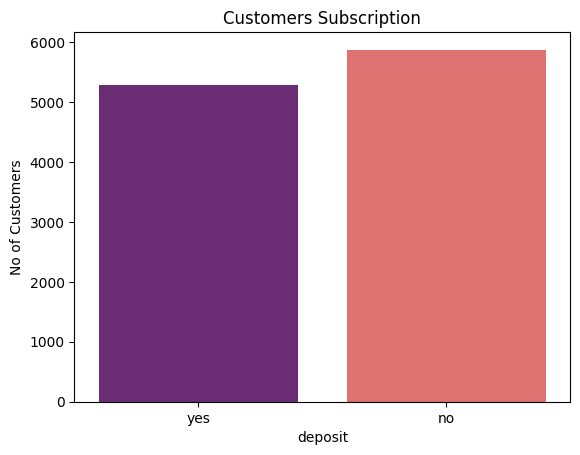

In [16]:
sns.countplot(x=df.deposit,hue = df.deposit,palette="magma")
plt.title("Customers Subscription")
plt.ylabel("No of Customers")
plt.show()

In [29]:
#which Age effect deposit
young_customer = df[
    (df.age > 18) & (df.age < 50)
]

Text(0.5, 1.0, 'Young Custmer Subscription')

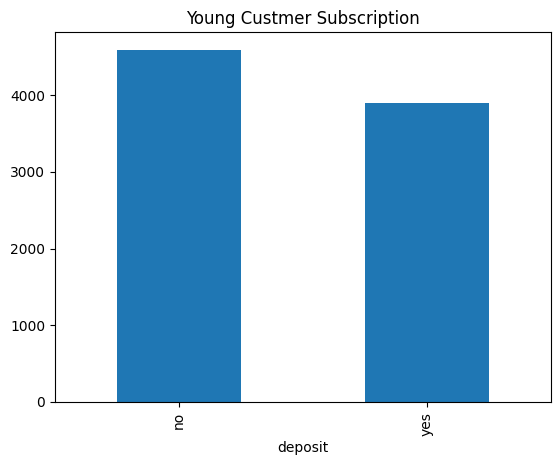

In [33]:
young_customer.deposit.value_counts().plot(kind="bar")
plt.title("Young Custmer Subscription")

In [35]:
# Old Customer Subscription 
old_customer = df[
    (df.age > 50) & (df.age < 100)
]

Text(0.5, 1.0, 'Old Customer Subscription')

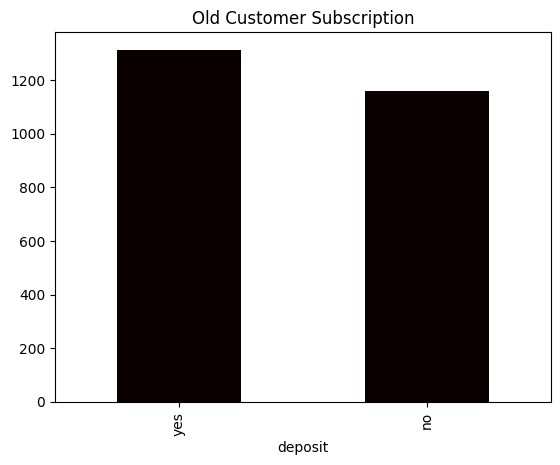

In [40]:
old_customer.deposit.value_counts().plot(kind = "bar",colormap="hot")
plt.title("Old Customer Subscription")

In [ ]:
# deposit customer percentage 
deposit_customer = df[df.deposit == "yes"]

In [ ]:

deposit_customer.deposit.count()/df.deposit.count()*100

np.float64(47.38398136534671)

In [55]:
# non depositor customer percentage
non_deposit_customer = df[df.deposit == "no"]

In [56]:
non_deposit_customer.deposit.count()/df.deposit.count()*100

np.float64(52.61601863465329)

In [58]:
# mean age value of depositor customer
deposit_age_mean = np.mean(deposit_customer.age)
print("Mean age value of depositor customer",deposit_age_mean)

Mean age value of depositor customer 41.670069956513515


In [60]:
# mean age value of Nondepositor customer
non_deposit_age_mean = np.mean(non_deposit_customer.age)
print("Mean age value of non_depositor customer",non_deposit_age_mean)

Mean age value of non_depositor customer 40.83739145240933


In [61]:
# Check deposit Customers are Educated or not
df.education.value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Text(0.5, 1.0, 'Education Rate deposit Customer')

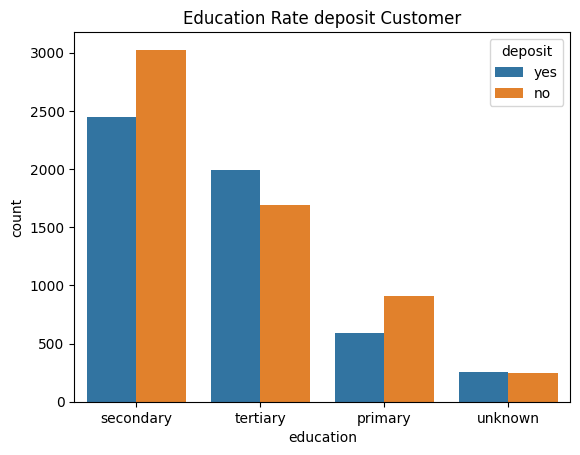

In [62]:
sns.countplot(x=df.education,hue=df.deposit,fill=True)
plt.title("Education Rate deposit Customer")

In [69]:
# Check Balance effect deposit
df.balance

0        2343
1          45
2        1270
3        2476
4         184
         ... 
11157       1
11158     733
11159      29
11160       0
11161       0
Name: balance, Length: 11162, dtype: int64

In [72]:
# Average Balance of the depositor and non depositor customer 
avg_bal = df.groupby("deposit")["balance"].mean()
print("Average Balance of Subscriber Or Non subscriber:",avg_bal)

Average Balance of Subscriber Or Non subscriber: deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64


<Axes: title={'center': 'Outliers In the Balance'}, xlabel='balance'>

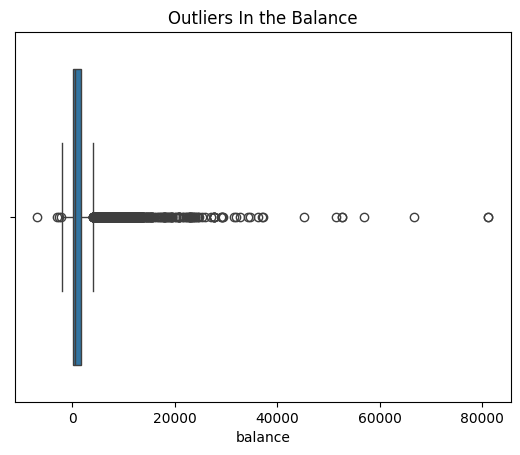

In [75]:
# check Outliers in the Balance 
plt.title("Outliers In the Balance")
sns.boxplot(df.balance,orient="h")

Text(0.5, 1.0, 'Loan wise Subcription')

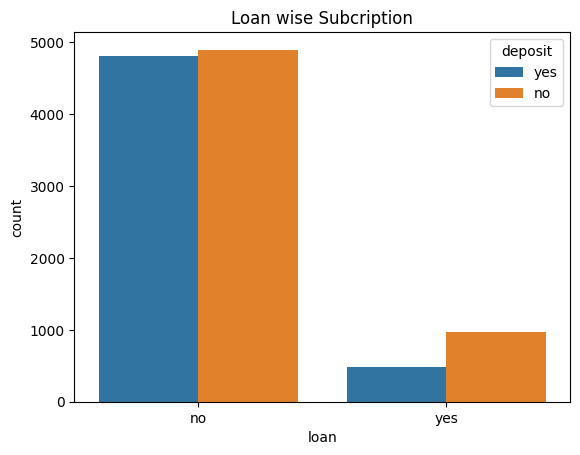

In [79]:
# check loan subscriber 
sns.countplot(x=df.loan,hue=df.deposit,)
plt.title("Loan wise Subcription")

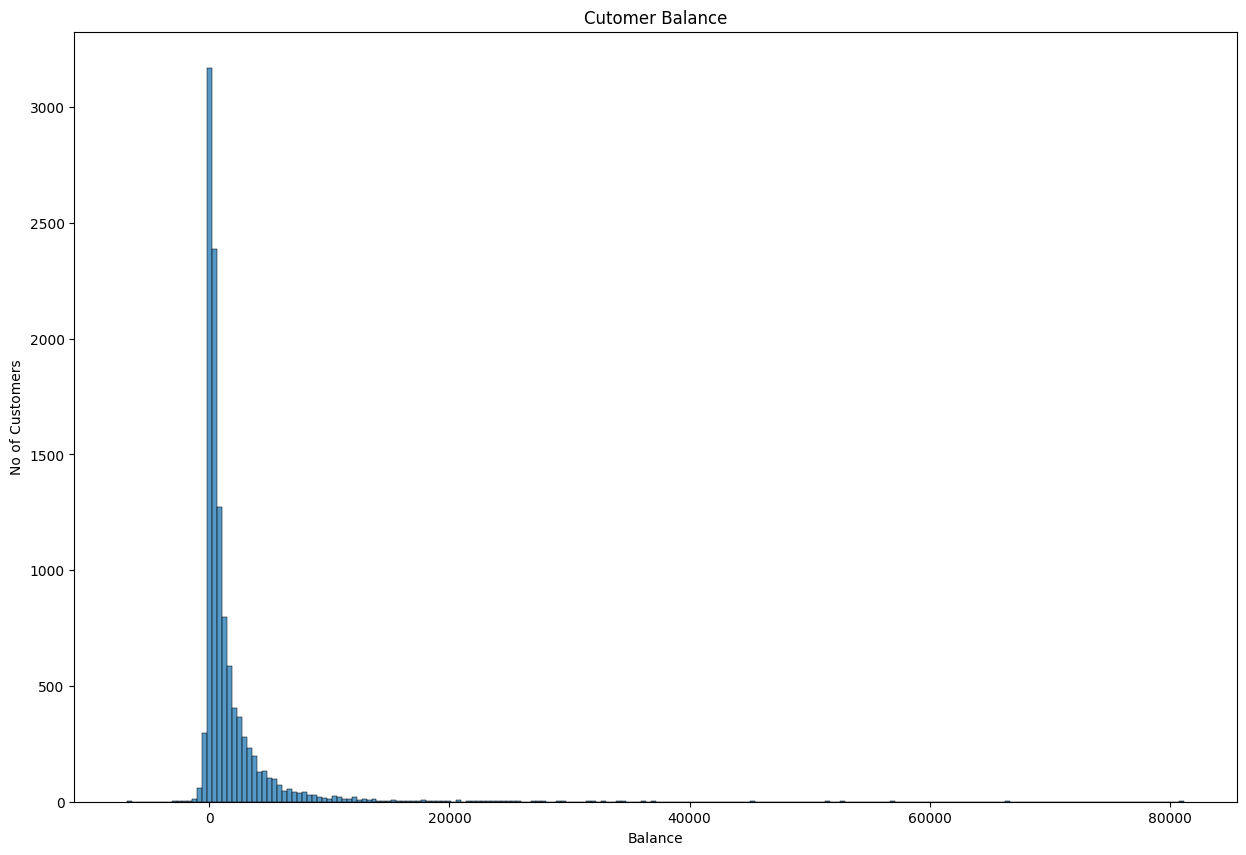

In [86]:
plt.figure(figsize=(15,10))
sns.histplot(df.balance)
plt.title("Cutomer Balance")
plt.xlabel("Balance")
plt.ylabel("No of Customers")
plt.show()

In [90]:
# check Wich Job effect subscription
df.job.value_counts()


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

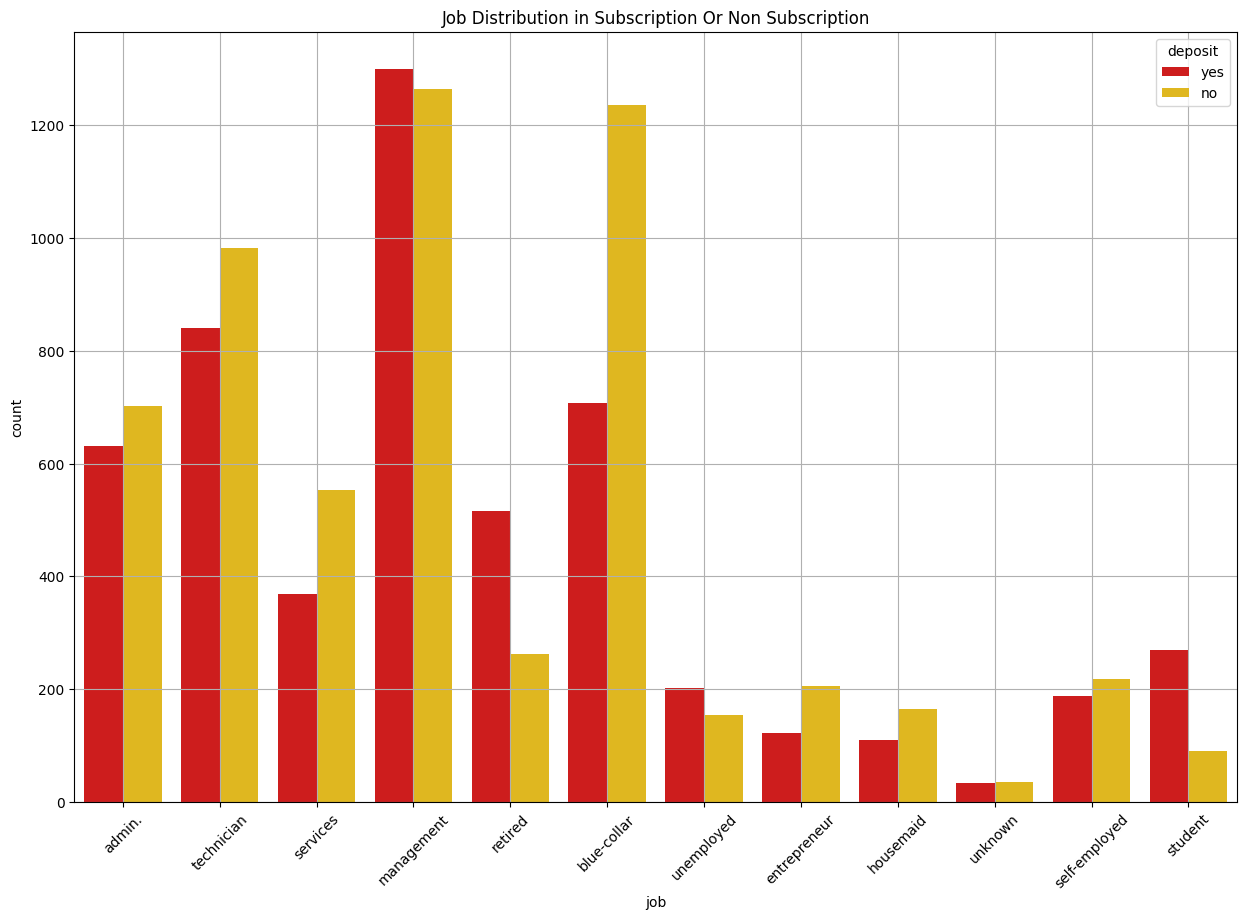

In [94]:
plt.figure(figsize=(15,10))
sns.countplot(x=df.job,hue=df.deposit,palette="hot",orient="y")
plt.title("Job Distribution in Subscription Or Non Subscription")
plt.xticks(rotation = 45)
plt.grid()
plt.show()


In [98]:
# which Month Most Subscription
df.month.value_counts()

month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64

<Axes: xlabel='deposit'>

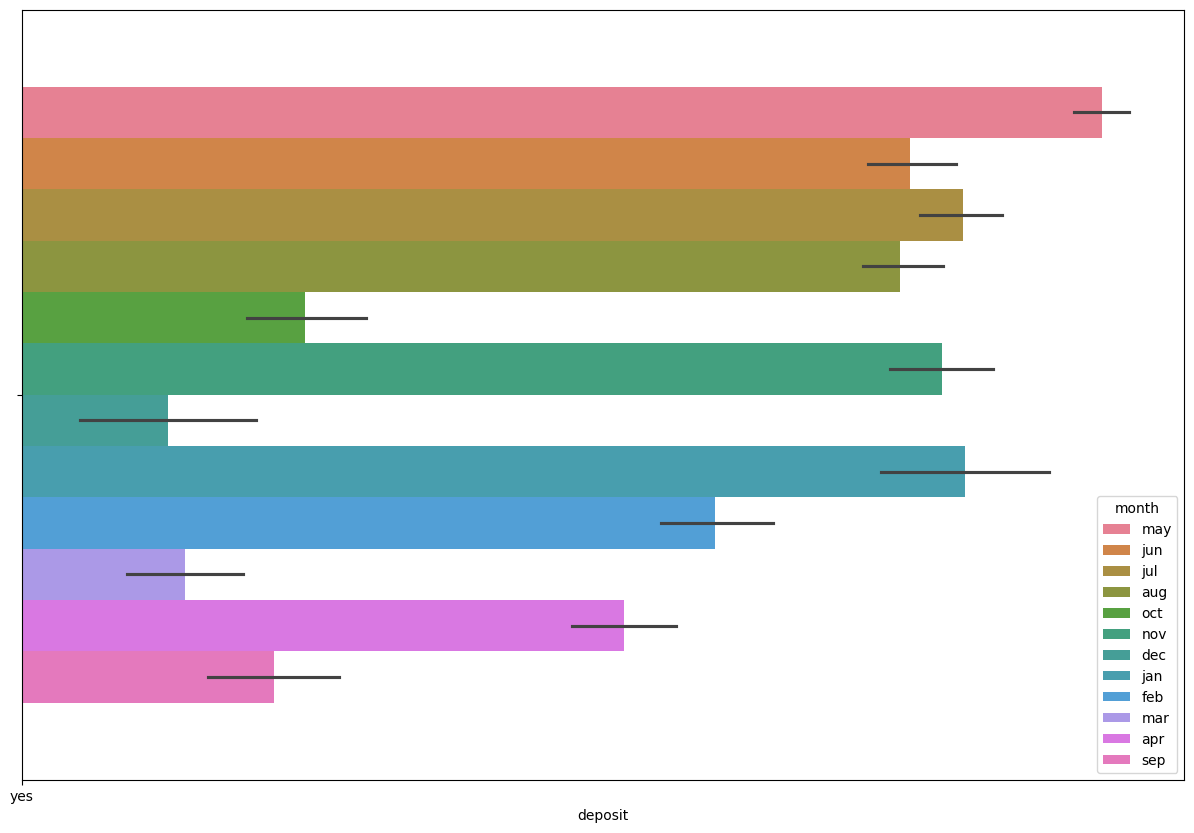

In [105]:
plt.figure(figsize=(15,10))
sns.barplot(x=df.deposit,hue=df.month,orient="h")

# Data Preprocessing 

In [106]:
df.deposit = df.deposit.replace({"yes":1,"no":0}).astype("int64")

In [107]:
num_var = df.select_dtypes(include=["int64"]).columns

In [109]:
# Check Correlation Graph 
cor_relation = df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous','deposit']].corr()

Text(0.5, 1.0, 'Correlation Graph With Numerical Variables')

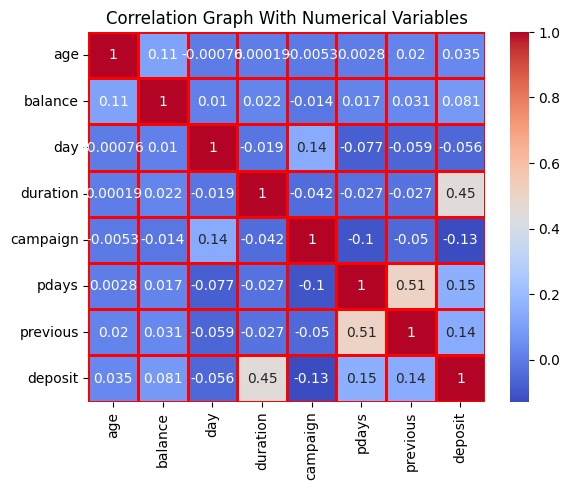

In [110]:
sns.heatmap(cor_relation,annot=True,cmap="coolwarm",linecolor="r",linewidths=2)
plt.title("Correlation Graph With Numerical Variables")

In [113]:
# select Catagorical variable 
cata_var = df.select_dtypes(include=("object","str")).columns
cata_var

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')

# Model Training

In [114]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

In [116]:
# X input 
x=df.drop(["deposit"],axis=1)

In [119]:
# Out put Target varible 
y = df["deposit"]

# Train Test Split

In [120]:
X_trian,X_test,y_train,y_test = train_test_split(x,y,random_state=5,test_size=5)

In [121]:
prerocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),num_var),
        ("cat",OneHotEncoder(drop="first"),cata_var)
    ],
    remainder="drop"
)

# Pipe Line

In [122]:
pipeline = Pipeline([
    ("prep",prerocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [123]:
pipeline.fit(X_trian,y_train)

ValueError: A given column is not a column of the dataframe